# Polymarket NBA Playoffs — Order Flow (OF) Data Download

**研究问题：** 能否用 Polymarket NBA 季后赛的订单簿（LOB）数据，通过深度学习预测合约的短期 mid-price 变动？

**本 notebook 的任务：**
1. 从 Telonex 下载构建 **Order Flow (OF)** 特征所需的订单簿数据
2. 验证数据结构、理解 Polymarket 的 LOB 微观结构
3. 为后续的 OF 特征工程和建模做准备

---

## 为什么只下载 `book_snapshot_25`？

Telonex 提供多种数据通道（channel）：

| Channel | 内容 | 我们要不要 |
|---|---|---|
| `quotes` | 只有最优买价/卖价（top-of-book，单档）| ❌ 信息不足，只能做 2 维 OF |
| `book_snapshot_25` | **完整的前 25 档** bid + ask 价格与数量 | ✅ **这是 OF 的输入来源** |
| `trades` | 实际成交记录 | ⭕ 可选（mid-price 也能从 book 算出）|

**Order Flow（订单流）的定义**依赖于「每一档买/卖挂单数量的变化量」。这必须有多档深度数据，
所以 `book_snapshot_25` 是唯一必需的通道——它既能构建 OF 输入，又能算出 mid-price 预测目标。

> 论文里的 OF 公式（10 档版）：
> $$OF_t = [\,bOF_t^{1}, aOF_t^{1},\; bOF_t^{2}, aOF_t^{2},\; \dots,\; bOF_t^{10}, aOF_t^{10}\,] \in \mathbb{R}^{20}$$
> 其中 $bOF$ 是 bid 侧数量变化、$aOF$ 是 ask 侧数量变化。没有多档数据就无法构建。

## 0. 环境准备

In [1]:
# 在 Colab 上运行时取消注释以安装依赖
# telonex[all]：Telonex 官方 Python SDK（含异步下载支持）
# pyarrow：读取 Telonex 提供的 parquet 列式存储文件
# !pip install "telonex[all]" pandas pyarrow matplotlib seaborn -q

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta

# Telonex SDK：download() 下载文件到本地，get_availability() 查询某合约有哪些日期/通道的数据
from telonex import download, get_availability

# pandas 显示设置：最多显示 60 列、浮点数保留 4 位小数（订单簿价格精度到 0.0001）
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 4)
sns.set_theme(style='whitegrid')
print('Setup complete.')

Setup complete.


In [ ]:
# ── 配置区 ────────────────────────────────────────────────────────────────────
API_KEY  = "tlx_fdc7cb68070057d89b1c6986e4702649" 
EXCHANGE = "polymarket"

# 唯一要下载的通道：完整 25 档订单簿快照
CHANNEL  = "book_snapshot_25"

# 数据保存路径
DATA_DIR = Path("../data")
RAW_DIR  = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"Channel:        {CHANNEL}")
print(f"Data directory: {RAW_DIR.resolve()}")

Channel:        book_snapshot_25
Data directory: /Users/christy/Desktop/3/26Spring_MS&E242/MS&E242_final/data/raw


## 1. 市场（合约）定义

Polymarket 上每个「问题」是一个 market，每个 market 有若干 **outcome（结果）**，每个 outcome 是一个
可独立交易的 0–1 美元二元合约（价格 = 市场对该结果发生概率的估计）。

我们要下载三类合约：

### A. 系列赛胜负合约（6 个）
「某轮系列赛谁会赢？」每个 market 有两个 outcome（两支球队）。两个 outcome 的价格互为镜像
（price_A ≈ 1 − price_B），所以**每个系列赛只取一方**即可，取双方会造成信息冗余/泄漏。

### B. 单边二元合约（3 个）
「Lakers 能否晋级总决赛 / Jokic 能否拿 MVP / SGA 能否拿 MVP」——取 `Yes` 这一侧。

### C. 「晋级总决赛」事件组（20 支球队）
`nba-playoffs-team-to-advance-to-nba-finals` 本身不是单一 market，而是 20 个独立的
「Will [Team] advance to the 2026 NBA Finals?」合约的集合。每个取 `Yes` 侧。

> **关于日期范围 `from`/`to`：** 每个合约的有效期 = 从季后赛开打到该结果被「确定」为止。
> 比如某队被淘汰，它的「晋级」合约就停止交易；系列赛结束，系列赛合约就结算。
> 日期来自前面用 `get_availability()` 查询的实际数据可用区间。

In [4]:
# ── A. 系列赛市场（每个取 outcome_id=0 那一方）──────────────────────────────────
# outcome：该侧球队名（会出现在下载文件名里，便于识别）
SERIES_MARKETS = [
    {"slug": "nba-playoffs-who-will-win-series-knicks-vs-76ers",        "outcome": "Knicks", "label": "Knicks vs 76ers",        "from": "2026-05-04", "to": "2026-05-12"},
    {"slug": "nba-playoffs-who-will-win-series-spurs-vs-timberwolves",  "outcome": "Spurs",  "label": "Spurs vs Timberwolves",  "from": "2026-05-01", "to": "2026-05-17"},
    {"slug": "nba-playoffs-who-will-win-series-timberwolves-vs-nuggets","outcome": "Wolves", "label": "Timberwolves vs Nuggets","from": "2026-04-17", "to": "2026-05-02"},
    {"slug": "nba-playoffs-who-will-win-series-knicks-vs-hawks",        "outcome": "Knicks", "label": "Knicks vs Hawks",        "from": "2026-04-17", "to": "2026-05-02"},
    {"slug": "nba-playoffs-who-will-win-series-suns-vs-thunder",        "outcome": "Suns",   "label": "Suns vs Thunder",        "from": "2026-04-18", "to": "2026-04-29"},
    {"slug": "nba-playoffs-who-will-win-series-spurs-vs-trail-blazers", "outcome": "Spurs",  "label": "Spurs vs Trail Blazers", "from": "2026-04-19", "to": "2026-04-30"},
]

# ── B. 单边二元合约（取 Yes 侧）─────────────────────────────────────────────────
BINARY_MARKETS = [
    {"slug": "will-los-angeles-lakers-advance-to-the-2026-nba-finals",   "outcome": "Yes", "label": "Lakers advance",   "from": "2026-04-13", "to": "2026-05-13"},
    {"slug": "will-nikola-jokic-win-the-2026-nba-finals-mvp",            "outcome": "Yes", "label": "Jokic Finals MVP", "from": "2026-04-13", "to": "2026-06-08"},
    {"slug": "will-shai-gilgeous-alexander-win-the-2026-nba-finals-mvp", "outcome": "Yes", "label": "SGA Finals MVP",   "from": "2026-04-13", "to": "2026-06-08"},
]

# ── C. 「晋级总决赛」事件组：20 支球队（全部取 Yes 侧）───────────────────────────
# from 统一是季后赛开打日 2026-04-13；to 是该队被淘汰（合约停止交易）的日期
TEAM_ADVANCE_MARKETS = [
    {"slug": "will-charlotte-hornets-advance-to-the-2026-nba-finals",      "outcome": "Yes", "label": "Charlotte Hornets",      "from": "2026-04-13", "to": "2026-04-19"},
    {"slug": "will-miami-heat-advance-to-the-2026-nba-finals",             "outcome": "Yes", "label": "Miami Heat",             "from": "2026-04-13", "to": "2026-04-16"},
    {"slug": "will-denver-nuggets-advance-to-the-2026-nba-finals",         "outcome": "Yes", "label": "Denver Nuggets",         "from": "2026-04-13", "to": "2026-05-02"},
    {"slug": "will-houston-rockets-advance-to-the-2026-nba-finals",        "outcome": "Yes", "label": "Houston Rockets",        "from": "2026-04-13", "to": "2026-05-03"},
    {"slug": "will-phoenix-suns-advance-to-the-2026-nba-finals",           "outcome": "Yes", "label": "Phoenix Suns",           "from": "2026-04-13", "to": "2026-04-29"},
    {"slug": "will-los-angeles-clippers-advance-to-the-2026-nba-finals",   "outcome": "Yes", "label": "LA Clippers",           "from": "2026-04-13", "to": "2026-04-17"},
    {"slug": "will-detroit-pistons-advance-to-the-2026-nba-finals",        "outcome": "Yes", "label": "Detroit Pistons",        "from": "2026-04-13", "to": "2026-05-19"},
    {"slug": "will-atlanta-hawks-advance-to-the-2026-nba-finals",          "outcome": "Yes", "label": "Atlanta Hawks",          "from": "2026-04-13", "to": "2026-05-02"},
    {"slug": "will-san-antonio-spurs-advance-to-the-2026-nba-finals",      "outcome": "Yes", "label": "San Antonio Spurs",      "from": "2026-04-13", "to": "2026-06-01"},
    {"slug": "will-minnesota-timberwolves-advance-to-the-2026-nba-finals", "outcome": "Yes", "label": "Minnesota Timberwolves", "from": "2026-04-13", "to": "2026-05-17"},
    {"slug": "will-boston-celtics-advance-to-the-2026-nba-finals",         "outcome": "Yes", "label": "Boston Celtics",         "from": "2026-04-13", "to": "2026-05-04"},
    {"slug": "will-cleveland-cavaliers-advance-to-the-2026-nba-finals",    "outcome": "Yes", "label": "Cleveland Cavaliers",    "from": "2026-04-13", "to": "2026-05-27"},
    {"slug": "will-orlando-magic-advance-to-the-2026-nba-finals",          "outcome": "Yes", "label": "Orlando Magic",          "from": "2026-04-13", "to": "2026-05-05"},
    {"slug": "will-new-york-knicks-advance-to-the-2026-nba-finals",        "outcome": "Yes", "label": "New York Knicks",        "from": "2026-04-13", "to": "2026-05-27"},
    {"slug": "will-toronto-raptors-advance-to-the-2026-nba-finals",        "outcome": "Yes", "label": "Toronto Raptors",        "from": "2026-04-13", "to": "2026-05-05"},
    {"slug": "will-philadelphia-76ers-advance-to-the-2026-nba-finals",     "outcome": "Yes", "label": "Philadelphia 76ers",     "from": "2026-04-13", "to": "2026-05-12"},
    {"slug": "will-oklahoma-city-thunder-advance-to-the-2026-nba-finals",  "outcome": "Yes", "label": "Oklahoma City Thunder",  "from": "2026-04-13", "to": "2026-06-01"},
    {"slug": "will-los-angeles-lakers-advance-to-the-2026-nba-finals",     "outcome": "Yes", "label": "LA Lakers",             "from": "2026-04-13", "to": "2026-05-13"},
    {"slug": "will-portland-trail-blazers-advance-to-the-2026-nba-finals", "outcome": "Yes", "label": "Portland Trail Blazers", "from": "2026-04-13", "to": "2026-04-30"},
    {"slug": "will-golden-state-warriors-advance-to-the-2026-nba-finals",  "outcome": "Yes", "label": "Golden State Warriors",  "from": "2026-04-13", "to": "2026-04-19"},
]

# 合并成一个总列表；Lakers 在 B 和 C 各出现一次，用 slug+outcome 去重
ALL_MARKETS = SERIES_MARKETS + BINARY_MARKETS + TEAM_ADVANCE_MARKETS
seen = set()
MARKETS = []
for m in ALL_MARKETS:
    key = (m["slug"], m["outcome"])
    if key not in seen:
        seen.add(key)
        MARKETS.append(m)

print(f"系列赛市场:     {len(SERIES_MARKETS)}")
print(f"单边二元合约:   {len(BINARY_MARKETS)}")
print(f"晋级事件组:     {len(TEAM_ADVANCE_MARKETS)} 支球队")
print(f"去重后总计:     {len(MARKETS)} 个合约要下载")

系列赛市场:     6
单边二元合约:   3
晋级事件组:     20 支球队
去重后总计:     28 个合约要下载


## 2. 下载数据

Telonex 按「天」存储：每个合约每天一个 parquet 文件。下载函数会把文件存到
`data/raw/book_snapshot_25/<slug>__<outcome>/` 目录下。

> **`to_date` 是开区间（exclusive）**——Telonex SDK 的 `to_date` 不包含当天，
> 所以我们给它 +1 天，确保最后一天的数据也被下载进来。

In [ ]:
def _plus_one_day(date_str):
    """把 'YYYY-MM-DD' 加一天，用于把 Telonex 的开区间 to_date 变成闭区间。"""
    d = datetime.strptime(date_str, "%Y-%m-%d") + timedelta(days=1)
    return d.strftime("%Y-%m-%d")


def download_book(slug, outcome, from_date, to_date):
    """下载单个合约的 book_snapshot_25 数据（所有日期）。

    返回成功下载的 parquet 文件数量。已存在的文件 Telonex 会自动跳过
    """
    # 每个合约用「slug + outcome」做文件夹名，避免同一系列赛两侧/不同合约冲突
    folder_name = f"{slug.replace('-', '_')}__{outcome}"
    save_dir = RAW_DIR / CHANNEL / folder_name
    save_dir.mkdir(parents=True, exist_ok=True)

    try:
        download(
            api_key=API_KEY,
            exchange=EXCHANGE,
            channel=CHANNEL,
            slug=slug,
            outcome=outcome,
            from_date=from_date,
            to_date=_plus_one_day(to_date),   # +1 天保证闭区间
            download_dir=str(save_dir),
            verbose=False,
        )
        n = len(list(save_dir.glob("*.parquet")))
        return n, None
    except Exception as e:
        return 0, str(e)

In [6]:
# ── 执行下载 ──────────────────────────────────────────────────────────────────
download_log = []

for i, m in enumerate(MARKETS, 1):
    n, err = download_book(m["slug"], m["outcome"], m["from"], m["to"])
    status = f"{n:3d} files" if err is None else f"ERROR: {err[:50]}"
    print(f"[{i:2d}/{len(MARKETS)}] {m['label']:24s} ({m['outcome']:7s}) → {status}")
    download_log.append({"label": m["label"], "outcome": m["outcome"],
                          "slug": m["slug"], "n_files": n, "error": err})

print("\n✅ 下载完成")
log_df = pd.DataFrame(download_log)
print(f"总文件数: {log_df['n_files'].sum()}")
display(log_df)

[ 1/28] Knicks vs 76ers          (Knicks ) →   8 files


[ 2/28] Spurs vs Timberwolves    (Spurs  ) →  16 files


[ 3/28] Timberwolves vs Nuggets  (Wolves ) →  15 files


[ 4/28] Knicks vs Hawks          (Knicks ) →  15 files


[ 5/28] Suns vs Thunder          (Suns   ) →  11 files


...

[25/28] Philadelphia 76ers       (Yes    ) →  29 files


[26/28] Oklahoma City Thunder    (Yes    ) →  49 files


[27/28] Portland Trail Blazers   (Yes    ) →  17 files


[28/28] Golden State Warriors    (Yes    ) →   6 files

✅ 下载完成
总文件数: 678


,label,outcome,slug,n_files,error
0,Knicks vs 76ers,Knicks,nba-playoffs-who-will-win-series-knicks-vs-76ers,8,None
1,Spurs vs Timberwolves,Spurs,nba-playoffs-who-will-win-series-spurs-vs-timb...,16,None
2,Timberwolves vs Nuggets,Wolves,nba-playoffs-who-will-win-series-timberwolves-...,15,None
3,Knicks vs Hawks,Knicks,nba-playoffs-who-will-win-series-knicks-vs-hawks,15,None
4,Suns vs Thunder,Suns,nba-playoffs-who-will-win-series-suns-vs-thunder,11,None
5,Spurs vs Trail Blazers,Spurs,nba-playoffs-who-will-win-series-spurs-vs-trai...,11,None
6,Lakers advance,Yes,will-los-angeles-lakers-advance-to-the-2026-nb...,30,None
7,Jokic Finals MVP,Yes,will-nikola-jokic-win-the-2026-nba-finals-mvp,56,None
8,SGA Finals MVP,Yes,will-shai-gilgeous-alexander-win-the-2026-nba-...,56,None
9,Charlotte Hornets,Yes,will-charlotte-hornets-advance-to-the-2026-nba...,6,None


## 3. 数据加载与 Schema 理解

加载一个**有真实流动性**的代表性合约（Spurs vs Trail Blazers 系列赛），看 `book_snapshot_25` 的列结构。

> 为什么不用 Lakers？后面第 6 节会发现：长周期的「晋级总决赛」合约订单簿中间是空的
> （做市商只挂在 0.001 和 0.999 两个极端），mid-price 无意义；而**近期对战的系列赛合约**
> 才有真正的双边盘口和有意义的价格发现。所以这里用系列赛合约做演示。

In [7]:
def load_book(slug, outcome):
    """加载某合约所有日期的 book_snapshot_25 文件，合并、解析时间戳、转数值类型。"""
    folder = RAW_DIR / CHANNEL / f"{slug.replace('-', '_')}__{outcome}"
    files = sorted(folder.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"没有找到文件：{folder}")

    # 合并所有天的文件
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

    # timestamp_us 是 Unix 微秒时间戳 → 转成带 UTC 时区的 datetime
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)
    return df, files


# 用流动性好的系列赛合约做演示（Spurs vs Trail Blazers，取 Spurs 侧）
SAMPLE_SLUG, SAMPLE_OUTCOME = "nba-playoffs-who-will-win-series-spurs-vs-trail-blazers", "Spurs"
SAMPLE_LABEL = "Spurs vs Blazers (Spurs)"
book, book_files = load_book(SAMPLE_SLUG, SAMPLE_OUTCOME)

print(f"加载文件数: {len(book_files)}")
print(f"总行数:     {len(book):,}")
print(f"日期范围:   {book['ts'].min().date()} → {book['ts'].max().date()}")
print(f"\n所有列名 ({len(book.columns)} 列):")
print(book.columns.tolist())

加载文件数: 11
总行数:     127,975
日期范围:   2026-04-19 → 2026-04-29

所有列名 (108 列):
['timestamp_us', 'local_timestamp_us', 'exchange', 'market_id', 'slug', 'asset_id', 'outcome', 'bid_price_0', 'bid_size_0', 'bid_price_1', 'bid_size_1', 'bid_price_2', 'bid_size_2', 'bid_price_3', 'bid_size_3', 'bid_price_4', 'bid_size_4', 'bid_price_5', 'bid_size_5', 'bid_price_6', 'bid_size_6', 'bid_price_7', 'bid_size_7', 'bid_price_8', 'bid_size_8', 'bid_price_9', 'bid_size_9', 'bid_price_10', 'bid_size_10', 'bid_price_11', 'bid_size_11', 'bid_price_12', 'bid_size_12', 'bid_price_13', 'bid_size_13', 'bid_price_14', 'bid_size_14', 'bid_price_15', 'bid_size_15', 'bid_price_16', 'bid_size_16', 'bid_price_17', 'bid_size_17', 'bid_price_18', 'bid_size_18', 'bid_price_19', 'bid_size_19', 'bid_price_20', 'bid_size_20', 'bid_price_21', 'bid_size_21', 'bid_price_22', 'bid_size_22', 'bid_price_23', 'bid_size_23', 'bid_price_24', 'bid_size_24', 'ask_price_0', 'ask_size_0', 'ask_price_1', 'ask_size_1', 'ask_price_2', 'as

In [8]:
# ── 识别订单簿的价格/数量列 ───────────────────────────────────────────────────
# Telonex 的 book_snapshot_25 列名是 0-indexed：
#   bid_price_0..24 / bid_size_0..24 / ask_price_0..24 / ask_size_0..24（每侧 25 档）
#   level 0 = 最优档（bid 出价最高 / ask 要价最低），编号越大离盘口越远
# 用 key=lambda 按数字后缀排序，保证 _0, _1, ..., _24 的正确顺序（字符串排序会把 _10 排到 _2 前面）
bid_p = sorted([c for c in book.columns if c.startswith("bid_price_")], key=lambda c: int(c.split("_")[-1]))
ask_p = sorted([c for c in book.columns if c.startswith("ask_price_")], key=lambda c: int(c.split("_")[-1]))
bid_s = sorted([c for c in book.columns if c.startswith("bid_size_")],  key=lambda c: int(c.split("_")[-1]))
ask_s = sorted([c for c in book.columns if c.startswith("ask_size_")],  key=lambda c: int(c.split("_")[-1]))

# 全部转为数值类型（Telonex 的价格/数量字段以字符串存储；空档位为 NaN）
# .copy() 消除「DataFrame 高度碎片化」的性能警告
book = book.copy()
for c in bid_p + ask_p + bid_s + ask_s:
    book[c] = pd.to_numeric(book[c], errors="coerce")

print(f"Bid 价格档位: {len(bid_p)}  →  {bid_p[:3]} ... {bid_p[-1]}")
print(f"Ask 价格档位: {len(ask_p)}  →  {ask_p[:3]} ... {ask_p[-1]}")
print(f"\n前 3 行（只看最优 3 档 level 0-2）:")
display(book[["ts"] + bid_p[:3] + bid_s[:3] + ask_p[:3] + ask_s[:3]].head(3))

Bid 价格档位: 25  →  ['bid_price_0', 'bid_price_1', 'bid_price_2'] ... bid_price_24
Ask 价格档位: 25  →  ['ask_price_0', 'ask_price_1', 'ask_price_2'] ... ask_price_24

前 3 行（只看最优 3 档 level 0-2）:


,ts,bid_price_0,bid_price_1,bid_price_2,bid_size_0,bid_size_1,bid_size_2,ask_price_0,ask_price_1,ask_price_2,ask_size_0,ask_size_1,ask_size_2
0,2026-04-19 01:07:24.303000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-19 01:07:31.400000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.9900,NaN,NaN,9999.0000,NaN,NaN
2,2026-04-19 01:07:57.709000+00:00,0.0200,NaN,NaN,200.0000,NaN,NaN,0.9900,NaN,NaN,9999.0000,NaN,NaN


## 4. LOB 微观结构分析

关键问题：
1. 每个快照实际有几档被填满？（决定 OF 向量能做多少维）
2. 真实的 mid-price 在哪里？（不是顶层 best bid/ask 的中点）

In [9]:
# ── 每个快照填满了多少档？ ─────────────────────────────────────────────────────
# notna() 统计非空价格档位数。Polymarket 流动性比股票薄，很多快照档位不满 25。
book["n_bid_levels"] = book[bid_p].notna().sum(axis=1)
book["n_ask_levels"] = book[ask_p].notna().sum(axis=1)

print("每个快照填满的 Bid 档位数分布:")
print(book["n_bid_levels"].describe().round(2).to_string())
print("\n每个快照填满的 Ask 档位数分布:")
print(book["n_ask_levels"].describe().round(2).to_string())

# 建议的 OF 向量维度：取 bid/ask 都能稳定填满的档数 × 2
rec_levels = int(min(book["n_bid_levels"].median(), book["n_ask_levels"].median()))
print(f"\n建议 OF 档数（取中位数较小侧）: {rec_levels} 档")
print(f"  → OF 向量维度 = {rec_levels} × 2 (bid+ask) = {rec_levels*2} 维")

每个快照填满的 Bid 档位数分布:
count   127975.0000
mean        24.5300
std          2.3500
min          0.0000
25%         25.0000
50%         25.0000
75%         25.0000
max         25.0000

每个快照填满的 Ask 档位数分布:
count   127975.0000
mean        17.4400
std          6.1700
min          0.0000
25%         13.0000
50%         19.0000
75%         22.0000
max         25.0000

建议 OF 档数（取中位数较小侧）: 19 档
  → OF 向量维度 = 19 × 2 (bid+ask) = 38 维


/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2392560344.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  book["n_bid_levels"] = book[bid_p].notna().sum(axis=1)
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2392560344.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  book["n_ask_levels"] = book[ask_p].notna().sum(axis=1)


In [10]:
# ── 真实 mid-price（用最优档 level-0 的买卖价）─────────────────────────────────
# 金融含义：mid = (最优买价 + 最优卖价) / 2，是市场对「该结果发生概率」的瞬时估计。
# 这是我们模型要预测短期变动的核心量（预测目标 target）。
# 注意：列是 0-indexed，最优档是 bid_price_0 / ask_price_0（不是 _1）。
book["best_bid"] = book["bid_price_0"]
book["best_ask"] = book["ask_price_0"]
book["mid"]      = (book["best_bid"] + book["best_ask"]) / 2
book["spread"]   = book["best_ask"] - book["best_bid"]

print(f"市场: {SAMPLE_LABEL}")
print("\n真实 mid-price (level-0) 统计:")
print(book["mid"].describe().round(4).to_string())
print("\n买卖价差 spread 统计:")
print(book["spread"].describe().round(4).to_string())
print(f"\n中位 spread: {book['spread'].median():.4f}  ({book['spread'].median()*100:.2f}¢)")
# 对系列赛合约，spread 通常只有 1-2¢，说明盘口紧、流动性好、mid-price 可信

市场: Spurs vs Blazers (Spurs)

真实 mid-price (level-0) 统计:
count   126310.0000
mean         0.8831
std          0.0800
min          0.4950
25%          0.8000
50%          0.8990
75%          0.9625
max          0.9985

买卖价差 spread 统计:
count   126310.0000
mean         0.0240
std          0.0293
min         -0.0160
25%          0.0080
50%          0.0170
75%          0.0330
max          0.9700

中位 spread: 0.0170  (1.70¢)


/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2933013536.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  book["best_bid"] = book["bid_price_0"]
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2933013536.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  book["best_ask"] = book["ask_price_0"]
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2933013536.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

In [11]:
# ── tick 频率：相邻快照的时间间隔 ─────────────────────────────────────────────
diffs = book["ts"].diff().dropna().dt.total_seconds()
active = diffs[diffs < 3600]   # 排除跨天/停盘的大间隔（>1小时）

print("活跃时段相邻快照间隔（秒）:")
print(active.describe().round(3).to_string())
print(f"\n中位间隔: {active.median():.3f}s  →  约 {1/max(active.median(),1e-9):.2f} 次更新/秒")

活跃时段相邻快照间隔（秒）:
count   127973.0000
mean         6.8810
std         42.2180
min          0.0000
25%          0.0200
50%          0.1160
75%          1.0840
max       3348.5060

中位间隔: 0.116s  →  约 8.62 次更新/秒


## 5. 可视化

/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/991040789.py:29: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/991040789.py:29: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/991040789.py:29: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/991040789.py:29: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/991040789.py:29: UserWarning: Glyph 20080 (\N{CJK UNIFIED IDEOGRAPH-4E70}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipyker

/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabto

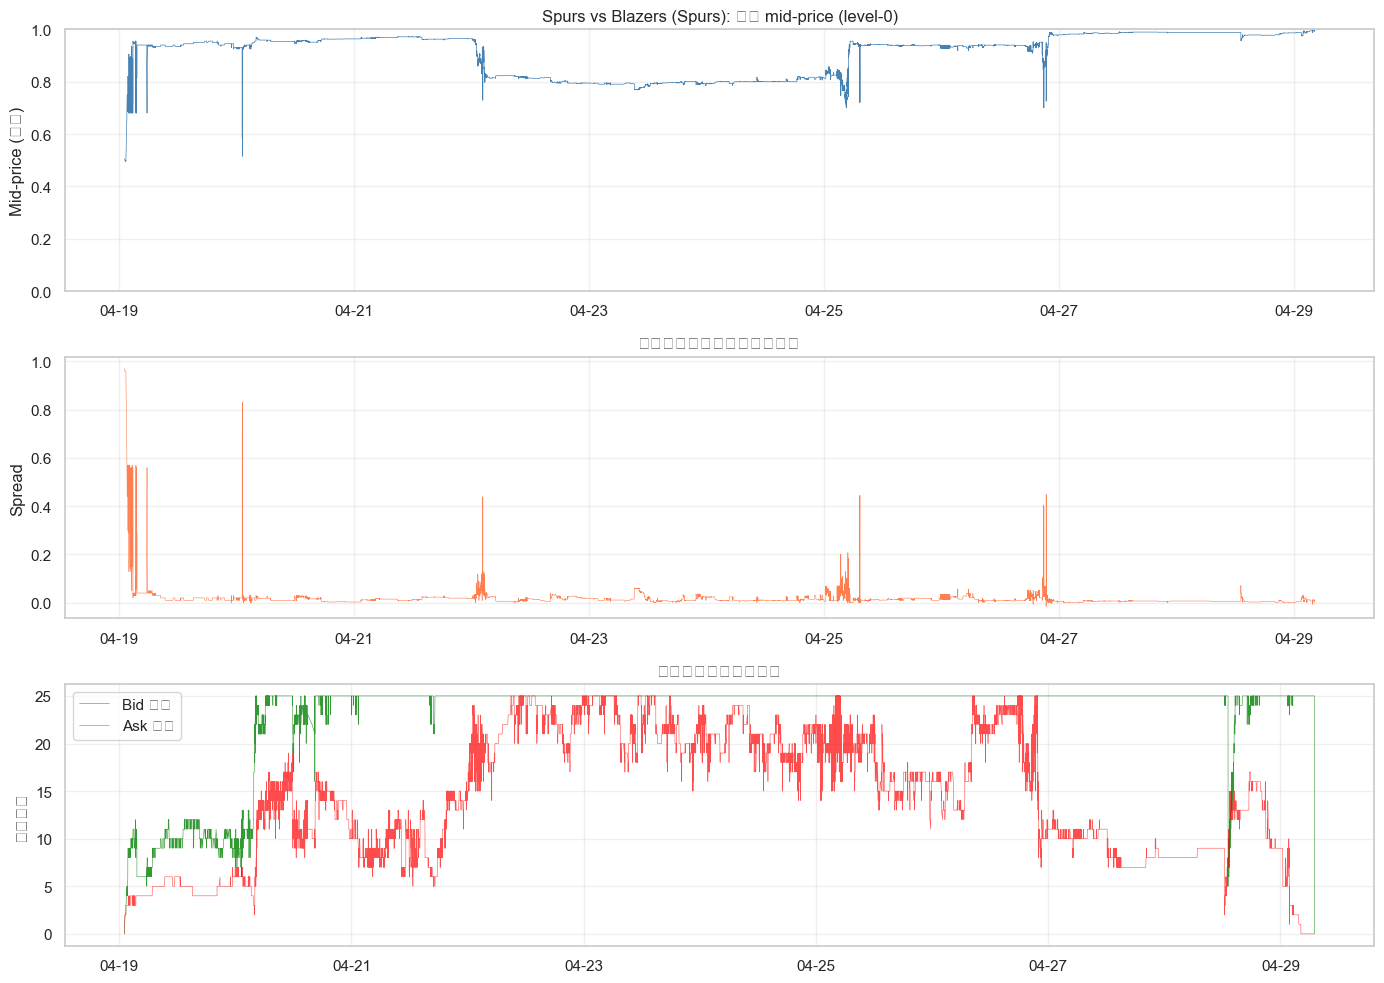

已保存 → results/sample_book_overview.png


In [12]:
# ── mid-price 与订单簿深度全景图 ──────────────────────────────────────────────
Path("../results").mkdir(exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: 真实 mid-price
axes[0].plot(book["ts"], book["mid"], lw=0.5, color="steelblue")
axes[0].set_ylabel("Mid-price (概率)")
axes[0].set_title(f"{SAMPLE_LABEL}: 真实 mid-price (level-0)")
axes[0].set_ylim(0, 1)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# Panel 2: 买卖价差
axes[1].plot(book["ts"], book["spread"], lw=0.4, color="coral")
axes[1].set_ylabel("Spread")
axes[1].set_title("买卖价差（越小流动性越好）")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# Panel 3: 订单簿深度（填满的档位数）
axes[2].plot(book["ts"], book["n_bid_levels"], lw=0.4, color="green", label="Bid 档数", alpha=0.8)
axes[2].plot(book["ts"], book["n_ask_levels"], lw=0.4, color="red",   label="Ask 档数", alpha=0.7)
axes[2].set_ylabel("填满档数")
axes[2].set_title("订单簿深度随时间变化")
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/sample_book_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("已保存 → results/sample_book_overview.png")

/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/900165063.py:19: UserWarning: Glyph 25346 (\N{CJK UNIFIED IDEOGRAPH-6302}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/900165063.py:19: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/900165063.py:19: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/900165063.py:19: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/900165063.py:19: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipyker

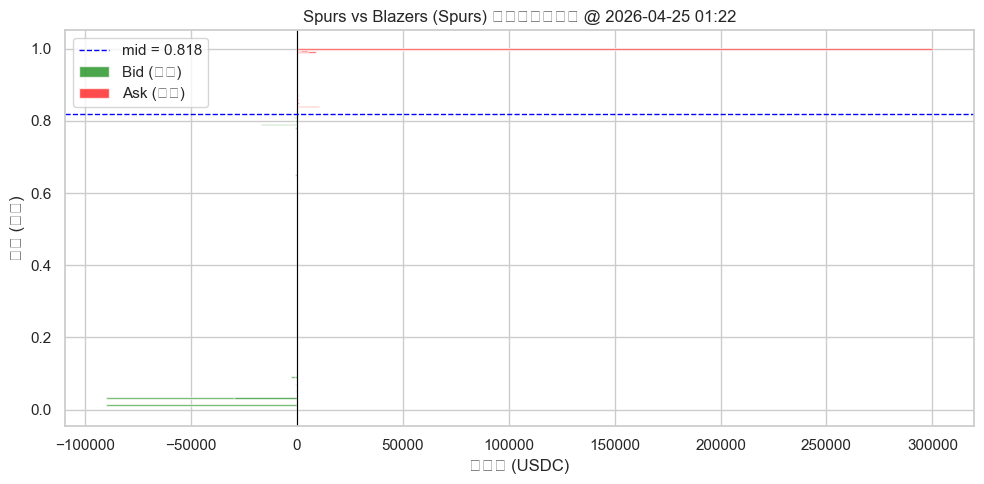

In [13]:
# ── 单个快照的订单簿深度剖面图 ────────────────────────────────────────────────
# 取中间某个快照，画出各档买/卖挂单量，直观展示流动性如何分布在不同价格上。
snap = book.iloc[len(book)//2]

bid_prices = [snap[c] for c in bid_p if pd.notna(snap[c])]
bid_sizes  = [snap[c] for c in bid_s][:len(bid_prices)]
ask_prices = [snap[c] for c in ask_p if pd.notna(snap[c])]
ask_sizes  = [snap[c] for c in ask_s][:len(ask_prices)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(bid_prices, [-s for s in bid_sizes], color="green", alpha=0.7, label="Bid (买单)", height=0.004)
ax.barh(ask_prices, ask_sizes,               color="red",   alpha=0.7, label="Ask (卖单)", height=0.004)
ax.axvline(0, color="black", lw=0.8)
ax.axhline(snap["mid"], color="blue", ls="--", lw=1, label=f"mid = {snap['mid']:.3f}")
ax.set_xlabel("挂单量 (USDC)")
ax.set_ylabel("价格 (概率)")
ax.set_title(f"{SAMPLE_LABEL} 订单簿快照剖面 @ {snap['ts']:%Y-%m-%d %H:%M}")
ax.legend()
plt.tight_layout()
plt.savefig("../results/sample_lob_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 全部市场数据量概览

统计每个合约下载到多少快照行，判断哪些适合做深度学习（行数太少的合约信息不足）。

In [14]:
# ── 逐合约统计行数与日期跨度 ──────────────────────────────────────────────────
stats = []
for m in MARKETS:
    folder = RAW_DIR / CHANNEL / f"{m['slug'].replace('-', '_')}__{m['outcome']}"
    files = sorted(folder.glob("*.parquet"))
    if files:
        n_rows = sum(len(pd.read_parquet(f, columns=["timestamp_us"])) for f in files)
        stats.append({"label": m["label"], "outcome": m["outcome"],
                      "n_rows": n_rows, "n_days": len(files)})
    else:
        stats.append({"label": m["label"], "outcome": m["outcome"], "n_rows": 0, "n_days": 0})

stats_df = pd.DataFrame(stats).sort_values("n_rows", ascending=False).reset_index(drop=True)
print(f"总快照行数: {stats_df['n_rows'].sum():,}")
display(stats_df)

总快照行数: 9,600,060


,label,outcome,n_rows,n_days
0,New York Knicks,Yes,1447705,44
1,Minnesota Timberwolves,Yes,840461,34
2,Cleveland Cavaliers,Yes,791610,44
3,SGA Finals MVP,Yes,779837,56
4,Philadelphia 76ers,Yes,760934,29
5,Denver Nuggets,Yes,753079,19
6,Houston Rockets,Yes,587469,20
7,Lakers advance,Yes,501907,30
8,Orlando Magic,Yes,382246,22
9,Timberwolves vs Nuggets,Wolves,347075,15


/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/3520111624.py:11: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/3520111624.py:11: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/3520111624.py:11: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/3520111624.py:11: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/3520111624.py:11: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/i

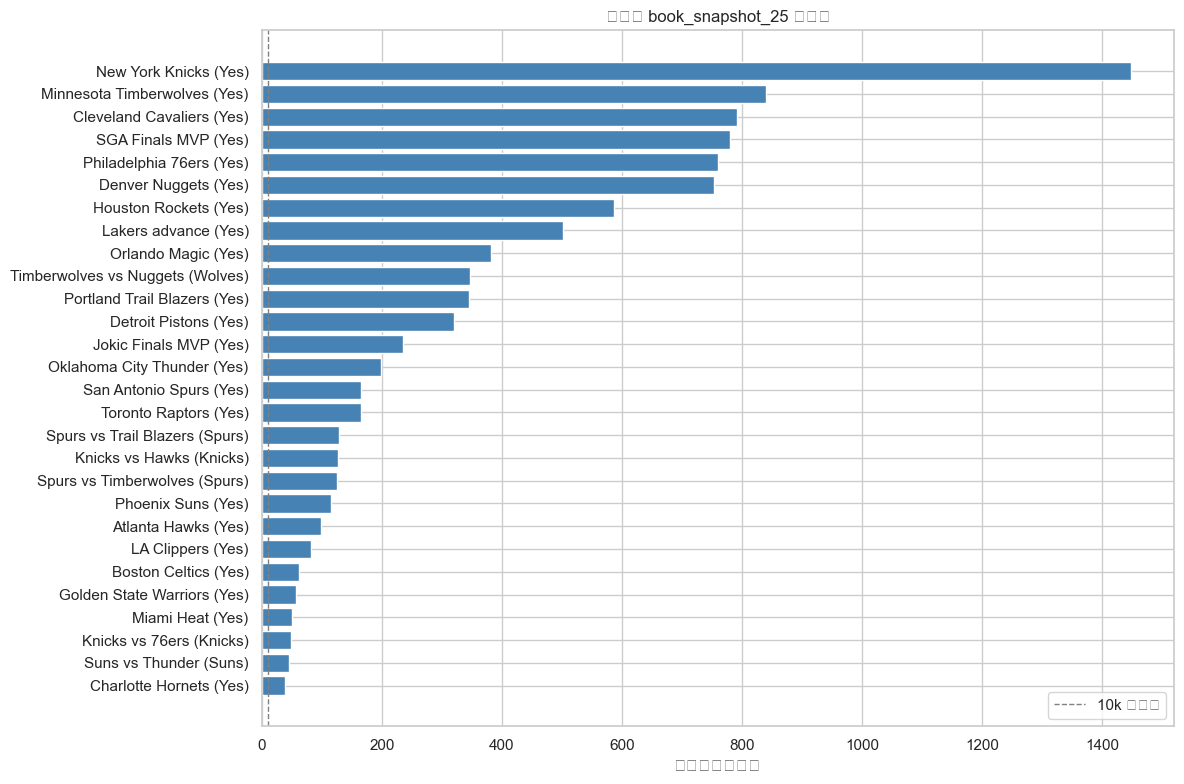

In [15]:
# ── 各合约数据量柱状图 ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
labels = stats_df["label"] + " (" + stats_df["outcome"] + ")"
colors = ["steelblue" if n >= 10000 else "lightcoral" for n in stats_df["n_rows"]]
ax.barh(labels, stats_df["n_rows"] / 1000, color=colors)
ax.axvline(10, ls="--", color="gray", lw=1, label="10k 行阈值")
ax.set_xlabel("快照行数（千）")
ax.set_title("各合约 book_snapshot_25 数据量")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("../results/market_data_volume.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.5 关键发现：哪些市场真正可用？（流动性筛选）

数据量大 ≠ 适合建模。一个合约可能有几十万行快照，但如果订单簿是空的，这些行毫无信息。

**Polymarket 不同类型市场的流动性差异极大：**

- **长周期 longshot 合约**（如「Lakers 晋级总决赛」「Jokic 拿 MVP」）：
  订单簿中间是空的，做市商只把单子挂在 0.001（底）和 0.999（顶）两个极端，
  spread 高达 0.8–0.9，best-bid/ask 的中点是「空洞的中点」，**不能用作 mid-price**。

- **近期对战的系列赛合约**（如「Spurs vs Blazers 谁赢」）：
  有真正的双边盘口，spread 只有 1–2¢，价格随比赛实时波动，**这才是适合 OF 建模的数据**。

下面用 **中位 spread** 和 **紧价差占比（spread < 0.05 的比例）** 量化每个合约的流动性，
据此筛选出真正可用于建模的合约。

In [16]:
# ── 逐合约计算流动性指标 ──────────────────────────────────────────────────────
def liquidity_metrics(slug, outcome):
    """读取某合约所有快照，只用最优档(level-0)算 spread，返回流动性指标。"""
    folder = RAW_DIR / CHANNEL / f"{slug.replace('-', '_')}__{outcome}"
    files = sorted(folder.glob("*.parquet"))
    if not files:
        return None
    # 只读最优档两列，节省内存
    parts = [pd.read_parquet(f, columns=["bid_price_0", "ask_price_0"]) for f in files]
    d = pd.concat(parts, ignore_index=True)
    d["bb"] = pd.to_numeric(d["bid_price_0"], errors="coerce")
    d["ba"] = pd.to_numeric(d["ask_price_0"], errors="coerce")
    d = d.dropna(subset=["bb", "ba"])
    if len(d) == 0:
        return None
    spread = d["ba"] - d["bb"]
    return {
        "valid_rows": len(d),
        "med_spread": float(spread.median()),
        "tight_frac": float((spread < 0.05).mean()),   # 紧价差(<0.05)占比
        "med_mid":    float(((d["bb"] + d["ba"]) / 2).median()),
    }


liq = []
for m in MARKETS:
    met = liquidity_metrics(m["slug"], m["outcome"])
    if met:
        liq.append({"label": m["label"], "outcome": m["outcome"], **met})

liq_df = pd.DataFrame(liq)
# 判定规则：紧价差占比 >= 60% 视为「可用于建模」
liq_df["usable"] = liq_df["tight_frac"] >= 0.60
liq_df = liq_df.sort_values("tight_frac", ascending=False).reset_index(drop=True)

print(f"可用于建模的合约: {liq_df['usable'].sum()} / {len(liq_df)}")
display(liq_df.style.format({"med_spread": "{:.4f}", "tight_frac": "{:.1%}", "med_mid": "{:.3f}"}))

可用于建模的合约: 14 / 28


,label,outcome,valid_rows,med_spread,tight_frac,med_mid,usable
0,Portland Trail Blazers,Yes,333821,0.0290,99.5%,0.016,True
1,Miami Heat,Yes,40246,0.0340,98.4%,0.021,True
2,Golden State Warriors,Yes,47176,0.0390,96.5%,0.026,True
3,Orlando Magic,Yes,377299,0.0210,94.7%,0.014,True
4,LA Clippers,Yes,80162,0.0420,94.4%,0.028,True
5,Suns vs Thunder,Suns,44340,0.0070,94.3%,0.011,True
6,Charlotte Hornets,Yes,20543,0.0290,94.1%,0.035,True
7,Knicks vs 76ers,Knicks,46929,0.0150,93.0%,0.870,True
8,Spurs vs Timberwolves,Spurs,123466,0.0100,91.8%,0.800,True
9,Timberwolves vs Nuggets,Wolves,344772,0.0100,91.6%,0.425,True


/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2945031255.py:16: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2945031255.py:16: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2945031255.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2945031255.py:16: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_79249/2945031255.py:16: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/i

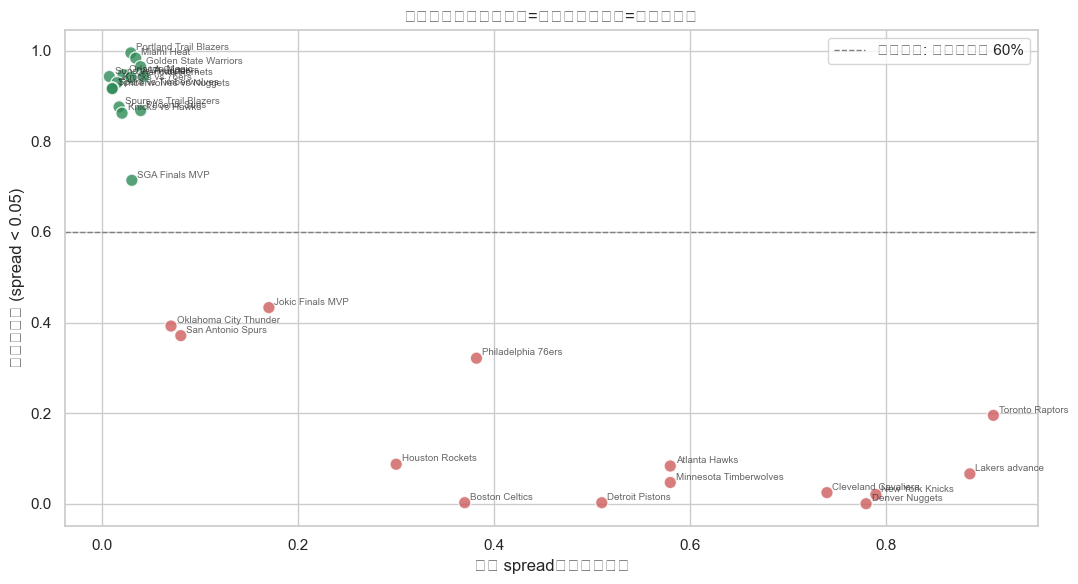


✅ 适合建模的合约（usable=True）：
                  label outcome  med_spread  tight_frac
 Portland Trail Blazers     Yes      0.0290      0.9954
             Miami Heat     Yes      0.0340      0.9837
  Golden State Warriors     Yes      0.0390      0.9649
          Orlando Magic     Yes      0.0210      0.9472
            LA Clippers     Yes      0.0420      0.9438
        Suns vs Thunder    Suns      0.0070      0.9432
      Charlotte Hornets     Yes      0.0290      0.9415
        Knicks vs 76ers  Knicks      0.0150      0.9297
  Spurs vs Timberwolves   Spurs      0.0100      0.9176
Timberwolves vs Nuggets  Wolves      0.0100      0.9165
 Spurs vs Trail Blazers   Spurs      0.0170      0.8761
           Phoenix Suns     Yes      0.0390      0.8680
        Knicks vs Hawks  Knicks      0.0200      0.8622
         SGA Finals MVP     Yes      0.0300      0.7140


In [17]:
# ── 流动性散点图：中位 spread vs 紧价差占比 ───────────────────────────────────
# 左下角（spread 小、紧价差占比高）= 流动性好的合约；右上角 = 订单簿空的 longshot
fig, ax = plt.subplots(figsize=(11, 6))
colors = ["seagreen" if u else "indianred" for u in liq_df["usable"]]
ax.scatter(liq_df["med_spread"], liq_df["tight_frac"], c=colors, s=80, alpha=0.8, edgecolor="white")

for _, r in liq_df.iterrows():
    ax.annotate(r["label"], (r["med_spread"], r["tight_frac"]),
                fontsize=7, alpha=0.7, xytext=(4, 2), textcoords="offset points")

ax.axhline(0.60, ls="--", color="gray", lw=1, label="可用阈值: 紧价差占比 60%")
ax.set_xlabel("中位 spread（越小越好）")
ax.set_ylabel("紧价差占比 (spread < 0.05)")
ax.set_title("各合约流动性筛选：绿=可用于建模，红=订单簿过空")
ax.legend()
plt.tight_layout()
plt.savefig("../results/liquidity_screen.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ 适合建模的合约（usable=True）：")
print(liq_df[liq_df["usable"]][["label", "outcome", "med_spread", "tight_frac"]].to_string(index=False))

## 7. 下一步：Order Flow (OF) 的构建（精确还原论文）

本 notebook 完成了 **数据下载 + 结构理解 + 流动性筛选**。下一步是 OF 特征工程（下个 notebook 实现）。
这里先把论文里 OF 的精确定义整理清楚，作为实现规范。

---

### Step 1 — 原材料：LOB 快照序列

论文用每侧 10 档，每个时刻 $t$ 的 LOB 快照是 40 维向量：

$$\mathbf{s}^{\text{LOB}}_t = \big(a^1_t, v^{1,a}_t, b^1_t, v^{1,b}_t,\; \ldots,\; a^{10}_t, v^{10,a}_t, b^{10}_t, v^{10,b}_t\big)^\top \in \mathbb{R}^{40}$$

- $a^i_t,\, b^i_t$：第 $i$ 档的 ask / bid **价格**
- $v^{i,a}_t,\, v^{i,b}_t$：第 $i$ 档的 ask / bid **数量（size）**

**OF 不是直接用 LOB，而是用相邻两个时刻快照之差 $(\mathbf{s}_t,\mathbf{s}_{t-1})$ 算出来的。**
关键动机：LOB 的价格/数量水平是**非平稳**的（随机游走般漂移），而 OF 是**平稳**的（增量），更适合做模型输入。

> 我们的数据：`book_snapshot_25` 提供最多 25 档（0-indexed `_0`..`_24`）。
> 实现时取最优的前 10 档（`_0`..`_9`）以精确对齐论文；不足 10 档的快照用 0 填充缺失档位。

---

### Step 2 — bid 侧订单流 $\text{bOF}$

对每一档 $i = 1, \ldots, 10$，比较 $t$ 与 $t-1$ 的 bid 价格，分三种情况：

$$\text{bOF}_{t,i} = \begin{cases} +\,v^{i,b}_t & \text{if } b^i_t > b^i_{t-1} \quad(\text{bid 价格上移}) \\[4pt] v^{i,b}_t - v^{i,b}_{t-1} & \text{if } b^i_t = b^i_{t-1} \quad(\text{价格不变}) \\[4pt] -\,v^{i,b}_t & \text{if } b^i_t < b^i_{t-1} \quad(\text{bid 价格下移}) \end{cases}$$

**三种情况的金融直觉：**

| 情况 | 含义 | $\text{bOF}$ |
|---|---|---|
| $b^i_t > b^i_{t-1}$ | 更高价的新买单进来（买方更激进）| $+v^{i,b}_t$（买压增加，正信号）|
| $b^i_t = b^i_{t-1}$ | 同价位挂单量变化 | $v^{i,b}_t - v^{i,b}_{t-1}$（净增减）|
| $b^i_t < b^i_{t-1}$ | 原最优买单被吃掉/撤单 | $-v^{i,b}_t$（买压减弱，负信号）|

---

### Step 3 — ask 侧订单流 $\text{aOF}$

对每一档 $i = 1, \ldots, 10$，符号与 bid 侧**相反**：

$$\text{aOF}_{t,i} = \begin{cases} -\,v^{i,a}_t & \text{if } a^i_t > a^i_{t-1} \quad(\text{ask 价格上移}) \\[4pt] v^{i,a}_t - v^{i,a}_{t-1} & \text{if } a^i_t = a^i_{t-1} \quad(\text{价格不变}) \\[4pt] +\,v^{i,a}_t & \text{if } a^i_t < a^i_{t-1} \quad(\text{ask 价格下移}) \end{cases}$$

**为什么符号相反？** 因为我们统一以「对买方（看涨）是否有利」为正方向：

| 情况 | 含义 | $\text{aOF}$ |
|---|---|---|
| $a^i_t > a^i_{t-1}$ | 卖方撤退到更高价位 | $-v^{i,a}_t$（卖压减弱，对买方利好）|
| $a^i_t = a^i_{t-1}$ | 同价位挂单量变化 | $v^{i,a}_t - v^{i,a}_{t-1}$（净增减）|
| $a^i_t < a^i_{t-1}$ | 更低价的新卖单进来（卖方更激进）| $+v^{i,a}_t$（卖压增加，对买方利空）|

---

### Step 4 — 拼接成 OF 向量

$$\text{OF}_t = \begin{pmatrix} \text{bOF}_t \\ \text{aOF}_t \end{pmatrix} \in \mathbb{R}^{20}, \qquad \text{bOF}_t \in \mathbb{R}^{10},\;\; \text{aOF}_t \in \mathbb{R}^{10}$$

bid 侧 10 档 + ask 侧 10 档 = **20 维向量**。

---

### Step 5 — 构建输入矩阵（lookback window）

把连续 $W = 100$ 个时刻的 OF 向量按时间堆叠：

$$\text{Input} = \big[\,\text{OF}_{t-99},\; \text{OF}_{t-98},\; \ldots,\; \text{OF}_t\,\big] \in \mathbb{R}^{100 \times 20}$$

即每个训练样本是一个 **100（时间步）× 20（特征）** 的矩阵，作为模型的输入。

---

### Step 6 — 预处理（严格防止 look-ahead bias）

1. **Winsorization（截尾）**：把训练集里低于 0.5% / 高于 99.5% 分位数的值截到分位点，消除极端异常值。
2. **Z-score 标准化**：
$$\tilde{x} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
   只用**训练集**的均值 $\mu_{\text{train}}$ 和标准差 $\sigma_{\text{train}}$，再把同一组参数套用到 validation / test 集——
   绝不能用 val/test 的统计量，否则会泄漏未来信息。

---

### 附：OF 与 OFI 的区别

论文还定义了 **OFI（Order Flow Imbalance）** 作为对比基准：

$$\text{OFI}_{t,i} = \text{bOF}_{t,i} - \text{aOF}_{t,i} \in \mathbb{R}^{10}$$

| | 维度 | 特点 |
|---|---|---|
| **OF** | 20 | bid / ask 分开保留，模型可对两侧做**不对称**处理 |
| **OFI** | 10 | bid − ask 的净失衡，更紧凑 |

论文结论：OF ≈ OFI（预测效果相近），但 OF 更灵活，所以我们主用 **OF**。

---

### 一句话总结

> OF 的构建是：对相邻两个 LOB 快照，按「价格上移 / 不变 / 下移」三种情况，
> 把每一档 bid 和 ask 的数量变化量化成一个**有符号**的数字；bid 与 ask 各 10 档合并成 20 维向量；
> 再把连续 100 个时刻的向量堆叠成 **100 × 20** 的输入矩阵。

In [18]:
# ── 把关键发现存成 JSON，供后续 notebook 使用 ─────────────────────────────────
# usable_markets：经流动性筛选后真正适合建模的合约清单（下个 notebook 直接读这个）
usable_markets = liq_df[liq_df["usable"]][["label", "outcome"]].to_dict(orient="records")

findings = {
    "channel": CHANNEL,
    "n_markets": len(MARKETS),
    "total_snapshots": int(stats_df["n_rows"].sum()),
    "sample_market": SAMPLE_SLUG,
    "recommended_of_levels": int(rec_levels),
    "recommended_of_dim": int(rec_levels * 2),
    "median_tick_interval_sec": float(active.median()),
    "n_usable_markets": int(liq_df["usable"].sum()),
    "usable_markets": usable_markets,
    "liquidity": liq_df.to_dict(orient="records"),
    "per_market": stats_df.to_dict(orient="records"),
}
out = Path("../results/data_findings.json")
with open(out, "w") as f:
    json.dump(findings, f, indent=2, default=str)
print(f"已保存 → {out}")
print(json.dumps({k: v for k, v in findings.items()
                  if k not in ('per_market', 'liquidity')}, indent=2, ensure_ascii=False))

已保存 → ../results/data_findings.json
{
  "channel": "book_snapshot_25",
  "n_markets": 28,
  "total_snapshots": 9600060,
  "sample_market": "nba-playoffs-who-will-win-series-spurs-vs-trail-blazers",
  "recommended_of_levels": 19,
  "recommended_of_dim": 38,
  "median_tick_interval_sec": 0.116,
  "n_usable_markets": 14,
  "usable_markets": [
    {
      "label": "Portland Trail Blazers",
      "outcome": "Yes"
    },
    {
      "label": "Miami Heat",
      "outcome": "Yes"
    },
    {
      "label": "Golden State Warriors",
      "outcome": "Yes"
    },
    {
      "label": "Orlando Magic",
      "outcome": "Yes"
    },
    {
      "label": "LA Clippers",
      "outcome": "Yes"
    },
    {
      "label": "Suns vs Thunder",
      "outcome": "Suns"
    },
    {
      "label": "Charlotte Hornets",
      "outcome": "Yes"
    },
    {
      "label": "Knicks vs 76ers",
      "outcome": "Knicks"
    },
    {
      "label": "Spurs vs Timberwolves",
      "outcome": "Spurs"
    },
    {
      